In [19]:
import pandas as pd

from geoai.utils_ds.dataframe_ops import DataFrameOperations
from geoai.utils_ds.preprocessing_ops import PreProcessingOperations
from geoai.utils_ds.visualize_ops import VisualizeOperations

df_ops = DataFrameOperations()
preprocess_ops = PreProcessingOperations()
visualize_ops = VisualizeOperations()

# READ DF

In [20]:
df = pd.read_csv("csv_files/dataset_no_duplicates.csv")
df.head()

,BLUE,GREEN,RED,NIR,SWIR,Landcover
0,835.3333,920.7500,1301.0000,1478.6666,1976.75,builtup
1,938.6667,966.3333,1153.0000,1376.0000,2025.20,builtup
2,871.0000,902.0000,946.0000,1218.0000,2025.20,builtup
3,985.0000,1050.0000,1114.6666,1573.0000,1974.75,builtup
4,940.2500,994.5000,1046.0000,1256.5000,1976.75,builtup


# SPLIT DATA

Data splitting involves dividing the dataset into separate subsets to train and test the model.
- Training set: Used to fit the model. It learns from this data.
- Test set: Used to assess the performance of the final model. It provides an unbiased evaluation.

In [21]:
# Split the data into train and test
X_train, X_test, y_train, y_test= df_ops.split_data(df, "Landcover")

# Save the data
X_train.to_csv("csv_files/X_train.csv", index=False)
X_test.to_csv("csv_files/X_test.csv", index=False)
y_train.to_csv("csv_files/y_train.csv", index=False)
y_test.to_csv("csv_files/y_test.csv", index=False)
X_train

,BLUE,GREEN,RED,NIR,SWIR
2103,350.0000,542.0000,323.0000,3277.0000,1975.3334
2325,390.0000,555.0000,380.0000,3016.6667,1991.0000
1532,1177.0000,1224.6666,1268.0000,1385.0000,1687.4000
2295,363.2000,546.5000,395.0000,3244.5000,2052.0000
107,1095.6000,1107.3334,1154.0000,1228.0000,1573.0000
...,...,...,...,...,...
1536,1208.6666,1318.4000,1333.0000,1462.0000,1813.4000
382,1199.3334,1279.3334,1488.0000,1630.0000,2486.2500
1037,740.0000,1040.0000,886.0000,3198.0000,2695.5000
347,1397.0000,1413.5000,1639.3334,1780.8572,2601.0000


In [22]:
X_test

,BLUE,GREEN,RED,NIR,SWIR
461,2824.6667,2901.3333,2884.0000,2976.0000,3537.0000
7,915.2000,919.0000,897.6667,1130.6666,2025.2000
1663,1006.3333,1156.5000,1112.0000,2234.0000,2176.7500
1487,1192.0000,1246.0000,1246.0000,1259.3334,1498.0000
141,837.5000,863.2500,904.2500,1124.0000,1607.5000
...,...,...,...,...,...
176,1601.2000,1722.0000,1714.0000,2141.0000,2055.0000
490,4043.0000,4331.0000,4272.0000,4188.0000,5132.6665
367,1252.0000,1308.0000,1410.0000,1752.0000,2470.0000
627,969.2500,1030.0000,1368.5000,1702.6666,2453.0000


# USING DOMAIN KNOWLEDGE

Feature engineering is the process of creating or improving features. Features are often created based on common sense, domain knowledge, or prior experience. There are certain common techniques for feature creation however there is no guarantee that creating new features will improve results. 

For example, since we know that we have classes of land cover, we can create new
features that can help us differentiate between these classes. We can compute
for NDVI, REI, and NDBI which can be derived from raw satellite data and serve
as important features that can enhance the performance of our model.

$$ NDVI = \frac{NIR - RED}{NIR + RED} $$
$$ NDBI = \frac{SWIR - NIR}{SWIR + NIR} $$
$$ REI = \frac{NIR - BLUE}{NIR + BLUE * NIR} $$

In [23]:
# Compute the indices for train
X_train["NDVI"] = (X_train["NIR"] - X_train["RED"]) / (X_train["NIR"] + X_train["RED"])
X_train["NDBI"] = (X_train["SWIR"] - X_train["NIR"]) / (X_train["SWIR"] + X_train["NIR"])
X_train["REI"] = (X_train["NIR"] - X_train["BLUE"]) / (X_train["NIR"] + X_train["BLUE"] * X_train["NIR"])
X_train.fillna(0, inplace=True) # Fill the NaN values with 0
# Save the data
X_train.to_csv("csv_files/X_train_with_indices.csv", index=False)

# Compute the indices for test
X_test["NDVI"] = (X_test["NIR"] - X_test["RED"]) / (X_test["NIR"] + X_test["RED"])
X_test["NDBI"] = (X_test["SWIR"] - X_test["NIR"]) / (X_test["SWIR"] + X_test["NIR"])
X_test["REI"] = (X_test["NIR"] - X_test["BLUE"]) / (X_test["NIR"] + X_test["BLUE"] * X_test["NIR"])
X_test.fillna(0, inplace=True) # Fill the NaN values with 0
# Save the data
X_test.to_csv("csv_files/X_test_with_indices.csv", index=False)
X_train.head()

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI
2103,350.0,542.0000,323.0,3277.0000,1975.3334,0.820556,-0.247826,0.002545
2325,390.0,555.0000,380.0,3016.6667,1991.0000,0.776251,-0.204819,0.002227
1532,1177.0,1224.6666,1268.0,1385.0000,1687.4000,0.044101,0.098425,0.000127
2295,363.2,546.5000,395.0,3244.5000,2052.0000,0.782937,-0.225149,0.002438
107,1095.6,1107.3334,1154.0,1228.0000,1573.0000,0.031066,0.123170,0.000098


# Binning/Categorization
 Separate feature values into several bins or categories. This can be useful
 when the feature values are continuous and we want to convert them into
 categories.
 

 ### One-Hot Encoding

One-hot encoding is a technique used to convert categorical data into a binary
(0 or 1) format, making it suitable for machine learning algorithms that require
numerical input. 


#### Original Data:

| Index | Category |
|-------|----------|
| 0     | A        |
| 1     | B        |
| 2     | A        |
| 3     | C        |
| 4     | B        |

#### One-Hot Encoded Output:

| Index | A   | B   | C   |
|-------|-----|-----|-----|
| 0     | 1.0 | 0.0 | 0.0 |
| 1     | 0.0 | 1.0 | 0.0 |
| 2     | 1.0 | 0.0 | 0.0 |
| 3     | 0.0 | 0.0 | 1.0 |
| 4     | 0.0 | 1.0 | 0.0 |

In [24]:
# Create binary NDVI
ndvi_binary_edges = [-float("inf"), 0.5, float("inf")] # The edges for the binary NDVI
ndvi_binary_labels = ["non_veg", "veg"] # The labels for the binary NDVI

# Create the binary NDVI for train and test
X_train,  X_test = preprocess_ops.binarize_or_categorize(X_train, X_test, "NDVI", "NDVI_binary", ndvi_binary_edges, ndvi_binary_labels)
X_train.head()

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,NDVI_binary
2103,350.0,542.0000,323.0,3277.0000,1975.3334,0.820556,-0.247826,0.002545,veg
2325,390.0,555.0000,380.0,3016.6667,1991.0000,0.776251,-0.204819,0.002227,veg
1532,1177.0,1224.6666,1268.0,1385.0000,1687.4000,0.044101,0.098425,0.000127,non_veg
2295,363.2,546.5000,395.0,3244.5000,2052.0000,0.782937,-0.225149,0.002438,veg
107,1095.6,1107.3334,1154.0,1228.0000,1573.0000,0.031066,0.123170,0.000098,non_veg


### Ordinal Encoding

Ordinal encoding is a technique used to convert categorical data into integer format, where each unique category is assigned a unique integer value. This method is useful when the categorical data has an inherent order or ranking.

#### Original Data:

| Index | Category |
|-------|----------|
| 0     | low      |
| 1     | medium   |
| 2     | high     |
| 3     | medium   |
| 4     | low      |

#### Ordinal Encoded Output:

| Index | Category (Encoded) |
|-------|--------------------|
| 0     | 1                |
| 1     | 2                |
| 2     | 0                |
| 3     | 2                |
| 4     | 1                |
dd

In [25]:
# Create categorical NDVI
ndvi_category_edges = [-float("inf"), 0.2, 0.5, float("inf")] # Define the edges for the categories
ndvi_category_labels = ["low_veg", "medium_veg", "high_veg"] # Define the labels for the categories

# Create the categorical NDVI for train and test
X_train,X_test = preprocess_ops.binarize_or_categorize(
    X_train, X_test, "NDVI", "NDVI_categorized", ndvi_category_edges, ndvi_category_labels
)
X_train.head()

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,NDVI_binary,NDVI_categorized
2103,350.0,542.0000,323.0,3277.0000,1975.3334,0.820556,-0.247826,0.002545,veg,high_veg
2325,390.0,555.0000,380.0,3016.6667,1991.0000,0.776251,-0.204819,0.002227,veg,high_veg
1532,1177.0,1224.6666,1268.0,1385.0000,1687.4000,0.044101,0.098425,0.000127,non_veg,low_veg
2295,363.2,546.5000,395.0,3244.5000,2052.0000,0.782937,-0.225149,0.002438,veg,high_veg
107,1095.6,1107.3334,1154.0,1228.0000,1573.0000,0.031066,0.123170,0.000098,non_veg,low_veg


In [26]:
X_train, X_test = preprocess_ops.make_one_hot_encoder(X_train, X_test, "NDVI_binary")
X_train.head()

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,NDVI_categorized,NDVI_binary_non_veg,NDVI_binary_veg
2103,350.0,542.0000,323.0,3277.0000,1975.3334,0.820556,-0.247826,0.002545,high_veg,0,1
2325,390.0,555.0000,380.0,3016.6667,1991.0000,0.776251,-0.204819,0.002227,high_veg,0,1
1532,1177.0,1224.6666,1268.0,1385.0000,1687.4000,0.044101,0.098425,0.000127,low_veg,1,0
2295,363.2,546.5000,395.0,3244.5000,2052.0000,0.782937,-0.225149,0.002438,high_veg,0,1
107,1095.6,1107.3334,1154.0,1228.0000,1573.0000,0.031066,0.123170,0.000098,low_veg,1,0


In [27]:
categories = [["low_veg", "medium_veg", "high_veg"]]
X_train, X_test = preprocess_ops.make_ordinal_encoder(X_train, X_test, "NDVI_categorized", categories)
X_train.head()

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,NDVI_binary_non_veg,NDVI_binary_veg,NDVI_categorized_encoded
2103,350.0,542.0000,323.0,3277.0000,1975.3334,0.820556,-0.247826,0.002545,0,1,2
2325,390.0,555.0000,380.0,3016.6667,1991.0000,0.776251,-0.204819,0.002227,0,1,2
1532,1177.0,1224.6666,1268.0,1385.0000,1687.4000,0.044101,0.098425,0.000127,1,0,0
2295,363.2,546.5000,395.0,3244.5000,2052.0000,0.782937,-0.225149,0.002438,0,1,2
107,1095.6,1107.3334,1154.0,1228.0000,1573.0000,0.031066,0.123170,0.000098,1,0,0


In [28]:
X_train_one_hot_ordinal = X_train[["NDVI_binary_non_veg", "NDVI_binary_veg", "NDVI_categorized_encoded"]]
X_test_one_hot_ordinal = X_test[["NDVI_binary_non_veg", "NDVI_binary_veg", "NDVI_categorized_encoded"]]
X_train_one_hot_ordinal.head()

,NDVI_binary_non_veg,NDVI_binary_veg,NDVI_categorized_encoded
2103,0,1,2
2325,0,1,2
1532,1,0,0
2295,0,1,2
107,1,0,0


# Log Transformation

Log transformation is a data transformation method used to reduce the skewness
of the data. It is used to make the data more normal distribution-like. This is
important because several statistical methods assume that the data is normally
distributed and might help to improve the accuracy of the model.

['BLUE', 'GREEN', 'RED', 'NIR', 'SWIR', 'NDVI', 'NDBI', 'REI']


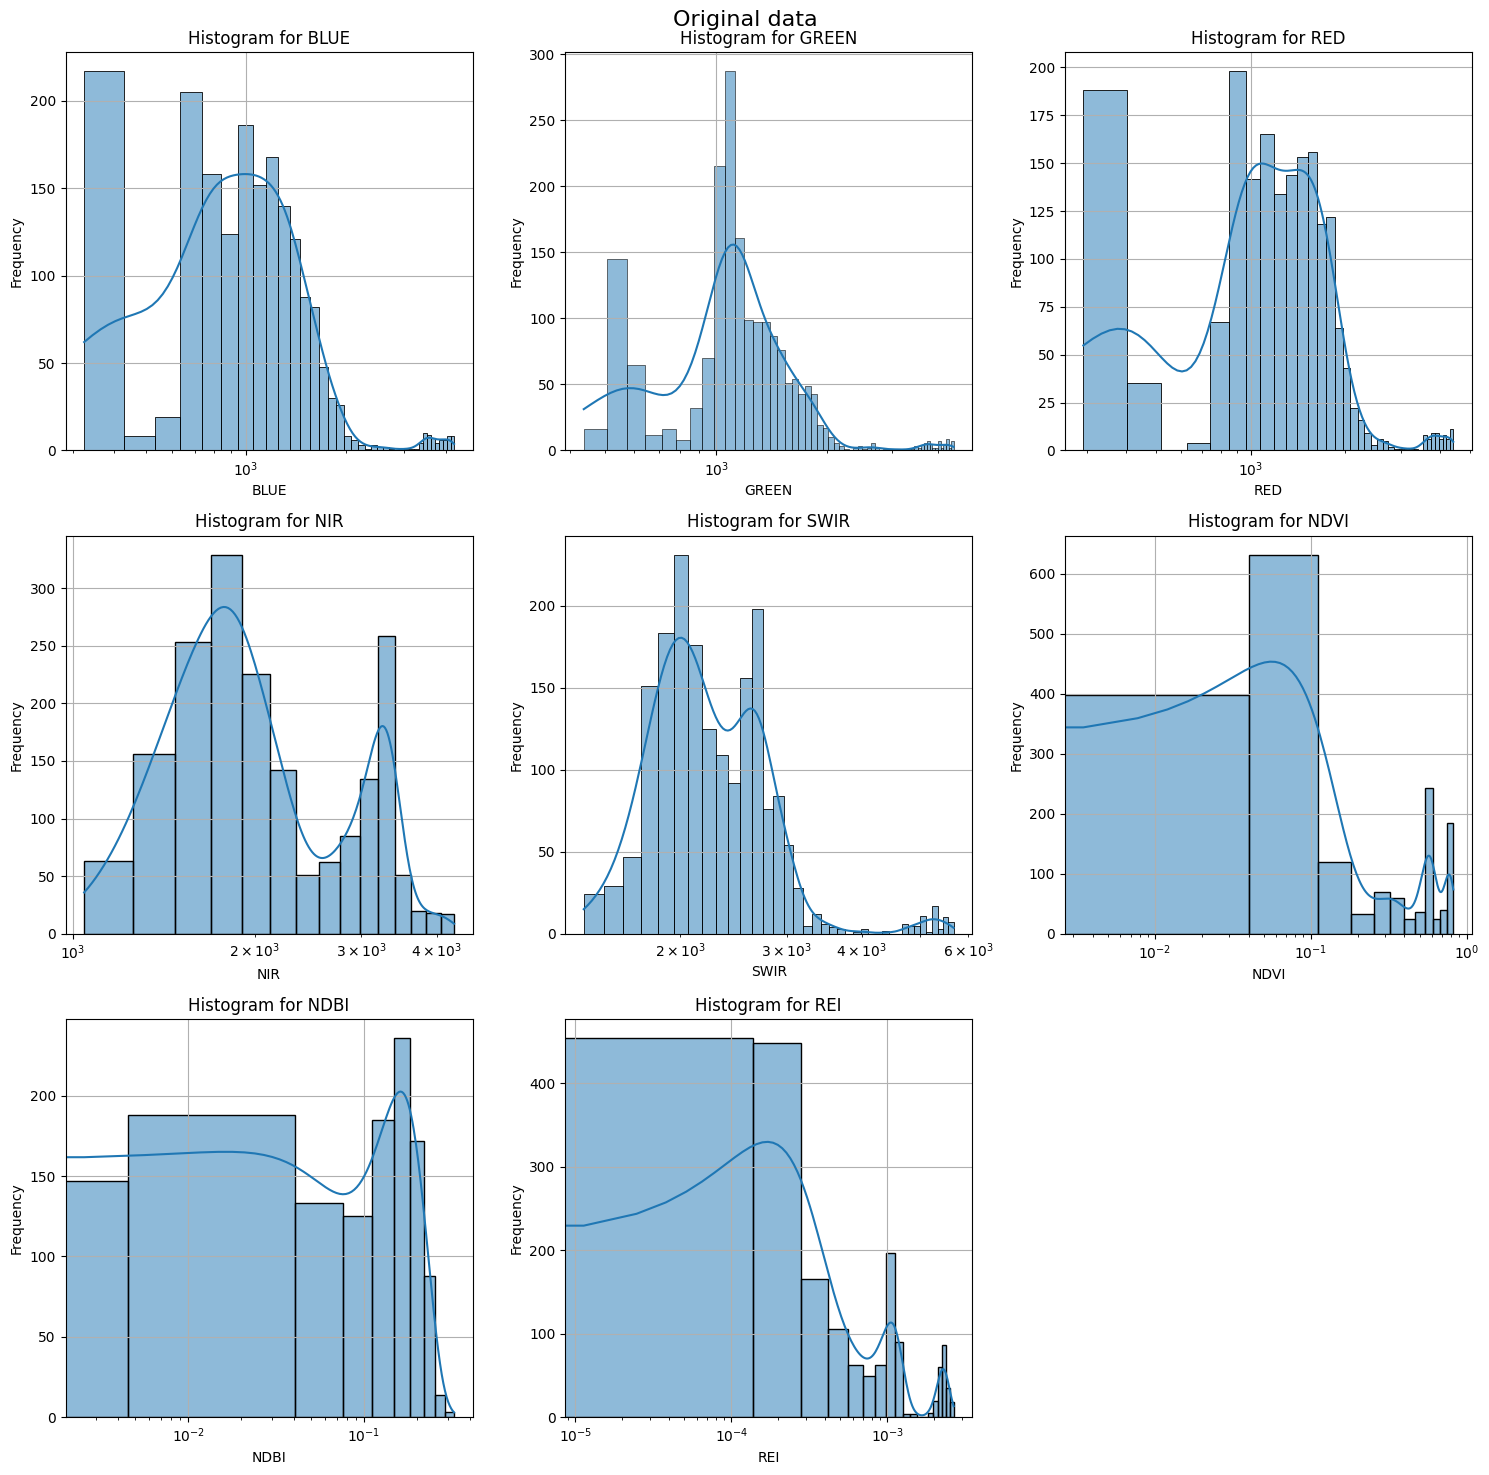

In [29]:
# Get the numerical columns
numerical_columns = X_train.select_dtypes(include=['float64']).columns.tolist()
print(numerical_columns)

# plot the histogram of the original data
visualize_ops.plot_histograms_with_kde(X_train, numerical_columns, "Original data")

          BLUE     GREEN       RED       NIR      SWIR      NDVI      NDBI  \
2103  5.860786  6.297109  5.780744  8.094989  7.588999  0.599142 -0.284788   
2325  5.968708  6.320768  5.942799  8.012239  7.596894  0.574505 -0.229186   
1532  7.071573  7.111240  7.145984  7.234177  7.431537  0.043156  0.093877   
2295  5.897703  6.305362  5.981414  8.085025  7.627057  0.578262 -0.255084   
107   6.999970  7.010613  7.051856  7.113956  7.361375  0.030594  0.116155   

           REI  
2103  0.002541  
2325  0.002224  
1532  0.000127  
2295  0.002435  
107   0.000098  


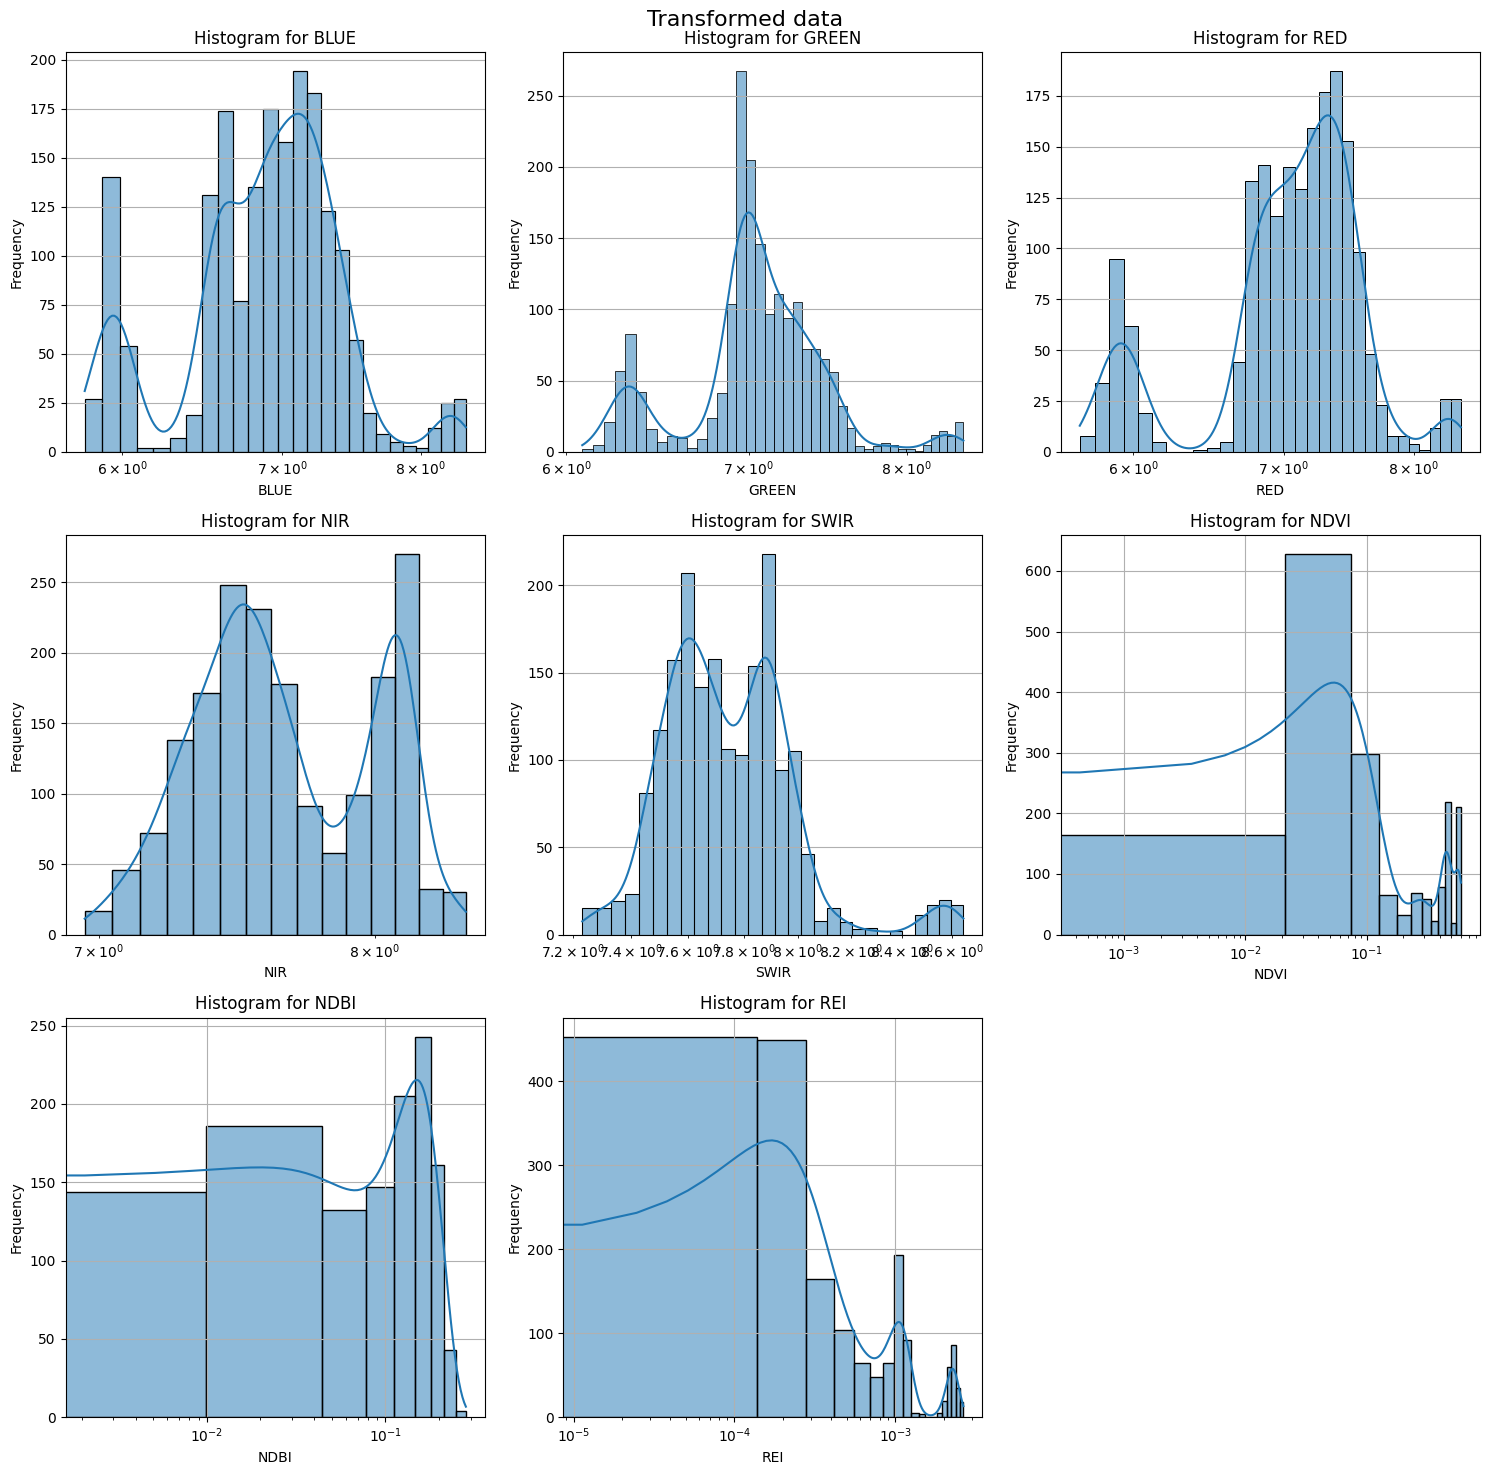

In [30]:
# log transform the data
X_train, X_test = preprocess_ops.log_transform(X_train, X_test, numerical_columns)
print(X_train.head())

# plot the histogram of the transformed data
visualize_ops.plot_histograms_with_kde(X_train, numerical_columns, "Transformed data")

# Polynomial transform

**Polynomial Features**: This method creates new features based on the original ones, including higher powers and combinations of those features.

The features of X have been transformed from [X1, X2] to [X1, X2, X1^2, X1X2,
X2^2].

Example:
two original features, X1 and X2.

Transformed Features: After applying the polynomial transform, new set of
features are created:

- X1 (the original feature)
- X2 (the original feature)
- X1^2 (the square of X1)
- X1 * X2 (the product of X1 and X2)
- X2^2 (the square of X2)


**Capture Combined Effects**: Sometimes the relationship between the target
variable and a combination of features is different from the relationship
between the target variable and each feature individually. Interaction terms
help capture these combined effects.

**Enhance Model Complexity**: By adding interaction terms, the model can
represent more complex relationships in the data which might (?) lead to better
predictions.

In [31]:
# Create the polynomial features for train and test
X_train, X_test = preprocess_ops.polynomial_transform(X_train, X_test, numerical_columns, 2)
X_train.head()

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,BLUE^2,BLUE GREEN,...,SWIR^2,SWIR NDVI,SWIR NDBI,SWIR REI,NDVI^2,NDVI NDBI,NDVI REI,NDBI^2,NDBI REI,REI^2
2103,5.860786,6.297109,5.780744,8.094989,7.588999,0.599142,-0.284788,0.002541,34.348815,36.906012,...,57.592900,4.546886,-2.161256,0.019287,0.358971,-0.170628,0.001523,0.081104,-0.000724,6.459135e-06
2325,5.968708,6.320768,5.942799,8.012239,7.596894,0.574505,-0.229186,0.002224,35.625470,37.726818,...,57.712805,4.364455,-1.741101,0.016899,0.330056,-0.131668,0.001278,0.052526,-0.000510,4.948067e-06
1532,7.071573,7.111240,7.145984,7.234177,7.431537,0.043156,0.093877,0.000127,50.007150,50.287656,...,55.227736,0.320717,0.697651,0.000947,0.001862,0.004051,0.000006,0.008813,0.000012,1.625104e-08
2295,5.897703,6.305362,5.981414,8.085025,7.627057,0.578262,-0.255084,0.002435,34.782903,37.187156,...,58.172005,4.410438,-1.945541,0.018575,0.334387,-0.147505,0.001408,0.065068,-0.000621,5.931214e-06
107,6.999970,7.010613,7.051856,7.113956,7.361375,0.030594,0.116155,0.000098,48.999577,49.074077,...,54.189848,0.225211,0.855063,0.000724,0.000936,0.003554,0.000003,0.013492,0.000011,9.665850e-09


In [32]:
X_test.columns

Index(['BLUE', 'GREEN', 'RED', 'NIR', 'SWIR', 'NDVI', 'NDBI', 'REI', 'BLUE^2',
       'BLUE GREEN', 'BLUE RED', 'BLUE NIR', 'BLUE SWIR', 'BLUE NDVI',
       'BLUE NDBI', 'BLUE REI', 'GREEN^2', 'GREEN RED', 'GREEN NIR',
       'GREEN SWIR', 'GREEN NDVI', 'GREEN NDBI', 'GREEN REI', 'RED^2',
       'RED NIR', 'RED SWIR', 'RED NDVI', 'RED NDBI', 'RED REI', 'NIR^2',
       'NIR SWIR', 'NIR NDVI', 'NIR NDBI', 'NIR REI', 'SWIR^2', 'SWIR NDVI',
       'SWIR NDBI', 'SWIR REI', 'NDVI^2', 'NDVI NDBI', 'NDVI REI', 'NDBI^2',
       'NDBI REI', 'REI^2'],
      dtype='object')

In [33]:
X_train_fe = pd.concat([X_train, X_train_one_hot_ordinal], axis=1)
X_test_fe = pd.concat([X_test, X_test_one_hot_ordinal], axis=1)
X_train_fe.head()

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,BLUE^2,BLUE GREEN,...,SWIR REI,NDVI^2,NDVI NDBI,NDVI REI,NDBI^2,NDBI REI,REI^2,NDVI_binary_non_veg,NDVI_binary_veg,NDVI_categorized_encoded
2103,5.860786,6.297109,5.780744,8.094989,7.588999,0.599142,-0.284788,0.002541,34.348815,36.906012,...,0.019287,0.358971,-0.170628,0.001523,0.081104,-0.000724,6.459135e-06,0,1,2
2325,5.968708,6.320768,5.942799,8.012239,7.596894,0.574505,-0.229186,0.002224,35.625470,37.726818,...,0.016899,0.330056,-0.131668,0.001278,0.052526,-0.000510,4.948067e-06,0,1,2
1532,7.071573,7.111240,7.145984,7.234177,7.431537,0.043156,0.093877,0.000127,50.007150,50.287656,...,0.000947,0.001862,0.004051,0.000006,0.008813,0.000012,1.625104e-08,1,0,0
2295,5.897703,6.305362,5.981414,8.085025,7.627057,0.578262,-0.255084,0.002435,34.782903,37.187156,...,0.018575,0.334387,-0.147505,0.001408,0.065068,-0.000621,5.931214e-06,0,1,2
107,6.999970,7.010613,7.051856,7.113956,7.361375,0.030594,0.116155,0.000098,48.999577,49.074077,...,0.000724,0.000936,0.003554,0.000003,0.013492,0.000011,9.665850e-09,1,0,0


In [34]:
# Export
X_train_fe.to_csv("csv_files/X_train_fe.csv", index=False)
X_test_fe.to_csv("csv_files/X_test_fe.csv", index=False)

# CONVERT LABEL STRING TO INTEGERS

In [35]:
y_train, y_test = preprocess_ops.make_label_encoder(y_train, y_test)

{'builtup': 0, 'grass': 1, 'road': 2, 'trees': 3}


In [36]:
y_train.to_csv("csv_files/y_train_encoded.csv", index=False)
y_test.to_csv("csv_files/y_test_encoded.csv", index=False)
y_train

2103    3
2325    3
1532    2
2295    3
107     0
       ..
1536    2
382     0
1037    1
347     0
823     0
Name: Landcover, Length: 1864, dtype: int32

END